# Assess impact of extinction law, filters on dereddening

In [7]:
import numpy as np

from astropy.table import Table
from astropy.table import hstack as table_hstack

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('figure_style.mplstyle')


In [5]:
# Read in isochrones
tm_sp_w = Table.read('isochrones/2mass_spitzer_wise.dat', format='ascii', comment='#', header_start=13)
ukidss = Table.read('isochrones/ukidss.dat', format='ascii', comment='#', header_start=13)
vvv = Table.read('isochrones/vista.dat', format='ascii', comment='#', header_start=13)
print(tm_sp_w.colnames, ukidss.colnames, vvv.colnames)

['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Jmag', 'Hmag', 'Ksmag', 'IRAC_3.6mag', 'IRAC_4.5mag', 'IRAC_5.8mag', 'IRAC_8.0mag', 'MIPS_24mag', 'MIPS_70mag', 'MIPS_160mag', 'W1mag', 'W2mag', 'W3mag', 'W4mag'] ['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Zmag', 'Ymag', 'Jmag', 'Hmag', 'Kmag'] ['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Zmag', 'Ymag', 'Jmag', 'Hmag', 'Ksmag']


In [56]:
# Merge
dat = table_hstack([tm_sp_w, ukidss, vvv], table_names=['2m', 'uk', 'vvv'])
dat.remove_columns(['Zini_uk', 'MH_uk', 'logAge_uk', 'Mini_uk', 'int_IMF_uk', 'Mass_uk', 
                    'logL_uk', 'logTe_uk', 'logg_uk', 'label_uk', 'McoreTP_uk', 'C_O_uk', 
                    'period0_uk', 'period1_uk', 'period2_uk', 'period3_uk', 'period4_uk', 
                    'pmode_uk', 'Mloss_uk', 'tau1m_uk', 'X_uk', 'Y_uk', 'Xc_uk', 'Xn_uk', 
                    'Xo_uk', 'Cexcess_uk', 'Z_uk', 'mbolmag_uk', 
                    'Zini_vvv', 'MH_vvv', 'logAge_vvv', 'Mini_vvv', 'int_IMF_vvv', 'Mass_vvv', 
                    'logL_vvv', 'logTe_vvv', 'logg_vvv', 'label_vvv', 'McoreTP_vvv', 'C_O_vvv', 
                    'period0_vvv', 'period1_vvv', 'period2_vvv', 'period3_vvv', 'period4_vvv', 
                    'pmode_vvv', 'Mloss_vvv', 'tau1m_vvv', 'X_vvv', 'Y_vvv', 'Xc_vvv', 'Xn_vvv', 
                    'Xo_vvv', 'Cexcess_vvv', 'Z_vvv', 'mbolmag_vvv'])
dat.rename_columns(['Zini_2m', 'MH_2m', 'logAge_2m', 'Mini_2m', 'int_IMF_2m', 'Mass_2m', 'logL_2m', 
                    'logTe_2m', 'logg_2m', 'label_2m', 'McoreTP_2m', 'C_O_2m', 'period0_2m', 
                    'period1_2m', 'period2_2m', 'period3_2m', 'period4_2m', 'pmode_2m', 'Mloss_2m', 
                    'tau1m_2m', 'X_2m', 'Y_2m', 'Xc_2m', 'Xn_2m', 'Xo_2m', 'Cexcess_2m', 'Z_2m', 'mbolmag_2m'], 
                    ['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 
                     'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 
                     'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 
                     'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag'])
dat.rename_columns(['Ksmag_2m', 'Kmag', 'Ksmag_vvv'],
                    ['Kmag_2m', 'Kmag_uk', 'Kmag_vvv'])
print(dat.colnames)

['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Jmag_2m', 'Hmag_2m', 'Kmag_2m', 'IRAC_3.6mag', 'IRAC_4.5mag', 'IRAC_5.8mag', 'IRAC_8.0mag', 'MIPS_24mag', 'MIPS_70mag', 'MIPS_160mag', 'W1mag', 'W2mag', 'W3mag', 'W4mag', 'Zmag_uk', 'Ymag_uk', 'Jmag_uk', 'Hmag_uk', 'Kmag_uk', 'Zmag_vvv', 'Ymag_vvv', 'Jmag_vvv', 'Hmag_vvv', 'Kmag_vvv']


## Visualize the filter differences: What should we use for $(H-4.5\mu m)_0$?

Recommendation: 
- Use the same value for all filter combinations: 0.08 or 0.1.
- AND consider targeting stars (that are not obviously foreground dwarfs) with $E(H-4.5\mu m)$ above some percentile of values in the field.
   - This percentile should be determined with synthetic populations, not the isochrones here.

[-1.  -0.5  0.   0.5] [ 9.30103  9.77815 10.     ]


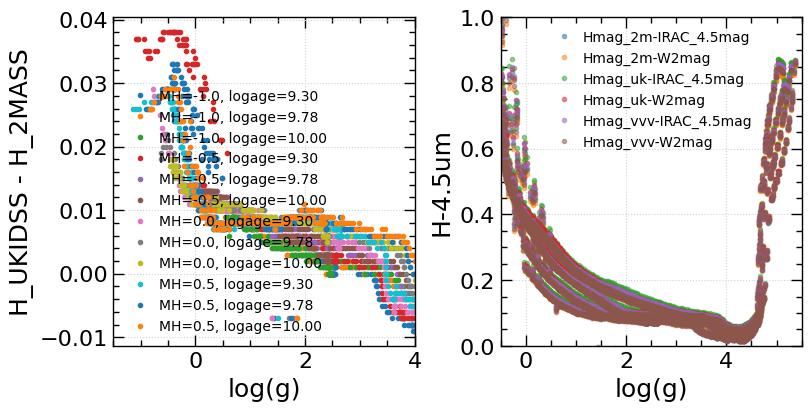

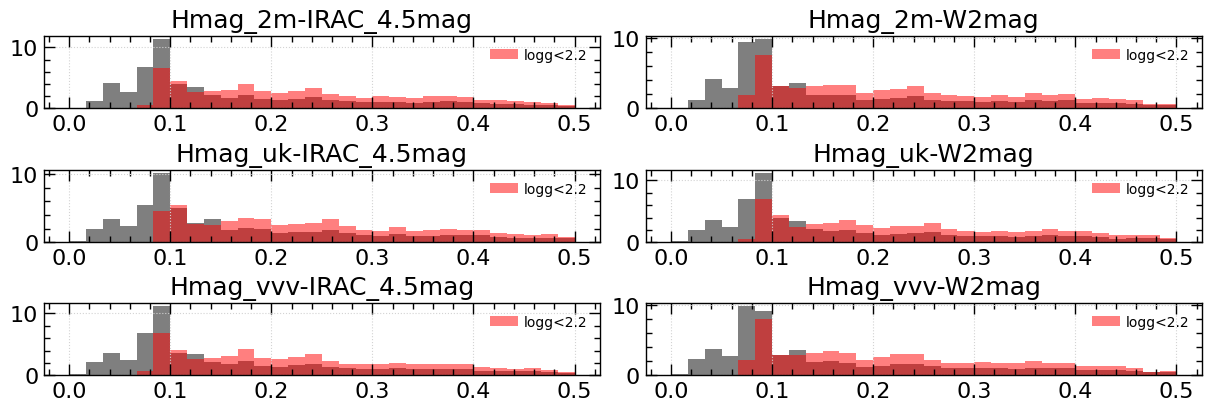

In [232]:
hmags = ['Hmag_2m','Hmag_uk','Hmag_vvv']
mirmags = ['IRAC_4.5mag', 'W2mag']
mh_array = np.array(np.unique(dat['MH']))
logage_array = np.array(np.unique(dat['logAge']))
print(mh_array, logage_array)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8,4), constrained_layout=True)

ax = axs[0]
for i_mh, this_mh in enumerate(mh_array):
    for i_logage, this_logage in enumerate(logage_array):
        gd = np.logical_and.reduce([dat['MH']==this_mh,
                                    dat['logAge']==this_logage])
        this_label='MH={:.1f}, logage={:.2f}'.format(this_mh, this_logage)
        ax.plot(dat['logg'][gd], np.subtract(dat['Hmag_uk'],dat['Hmag_2m'])[gd],
                 '.', label=this_label)
ax.set_xlim([-1.5,4])
ax.set_xlabel('log(g)')
ax.set_ylabel('H_UKIDSS - H_2MASS')
ax.legend()

ax = axs[1]
for this_hmag in hmags:
    for this_mirmag in mirmags:
        this_label=this_hmag+'-'+this_mirmag
        ax.plot(dat['logg'], np.subtract(dat[this_hmag], dat[this_mirmag]), '.',
                alpha=0.5, label=this_label)
ax.legend()
ax.set_xlim([-0.5,5.5])
ax.set_ylim([0,1])
ax.set_xlabel('log(g)')
ax.set_ylabel('H-4.5um')


#fig = plt.figure(figsize=(8,4))
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12,4), constrained_layout=True)
color_rng = [0,0.5]
color_nbins = 30
logg_max = 2.2
gi = (dat['logg'] < logg_max)


this_ax = 0
for this_hmag in hmags:
    for this_mirmag in mirmags:
        this_label=this_hmag+'-'+this_mirmag
        ax = axs.flatten()[this_ax]
        _=ax.hist(np.subtract(dat[this_hmag], dat[this_mirmag]), range=color_rng, bins=color_nbins, 
                  color='k', alpha=0.5, density=True)
        _=ax.hist(np.subtract(dat[this_hmag][gi], dat[this_mirmag][gi]), range=color_rng, bins=color_nbins, 
                  color='r', alpha=0.5, density=True, label='logg<{}'.format(logg_max))
        ax.set_title(this_label)
        ax.legend()
        this_ax = this_ax+1

## Test effects of dereddening decisions 

In [201]:
filters = np.array(['Jmag_2m','Jmag_uk','Jmag_vvv',
                    'Hmag_2m','Hmag_uk','Hmag_vvv',
                    'Kmag_2m','Kmag_uk','Kmag_vvv',
                    'IRAC_3.6mag', 'IRAC_4.5mag', 'IRAC_5.8mag', 'IRAC_8.0mag',
                    'W1mag', 'W2mag', 'W3mag', 'W4mag'])
filter_waves = np.array([12375.60, 12510.26, 12771.24,
                         16476.02, 16381.01, 16467.76,
                         21620.75, 22086.14, 21475.88, 
                         35612.35, 45096.26, 56894.50, 79576.25, 
                         33791.90, 46292.96, 123337.67, 222532.73])/1e4

def get_extinction(wave, aks=1.0, beta=-1.8):
    wave_ks = 2.162075 #microns
    return aks * (wave/wave_ks)**beta

def get_rjce_coeff(beta=-1.8, nirdata='2MASS', mirdata='IRAC'):
    if nirdata=='2MASS':
        h_wave = filter_waves[3]
        k_wave = filter_waves[6]
    elif nirdata=='UKIDSS':
        h_wave = filter_waves[4]
        k_wave = filter_waves[7]
    elif nirdata=='VVV':
        h_wave = filter_waves[5]
        k_wave = filter_waves[8]
    if mirdata=='IRAC':
        w2_wave = filter_waves[10]
    elif mirdata=='WISE':
        w2_wave = filter_waves[14]
    coeff = ((h_wave/k_wave)**beta - (w2_wave/k_wave)**beta)**(-1)
    return coeff

def get_rjce_ejkak(beta=-1.8, nirdata='2MASS'):
    if nirdata=='2MASS':
        j_wave = filter_waves[0]
        k_wave = filter_waves[6]
    elif nirdata=='UKIDSS':
        j_wave = filter_waves[1]
        k_wave = filter_waves[7]
    elif nirdata=='VVV':
        j_wave = filter_waves[2]
        k_wave = filter_waves[8]
    ejkak = (j_wave/k_wave)**beta
    return ejkak - 1

def test_dereddening(aks=1.0, distmod=14.5, beta=-1.8, 
                     rjce_h450=0.08, rjce_coeff=0.918, ejk_ak=1.5, jk0_min=0.65, 
                     nirdata='2MASS', mirdata='IRAC'):
    #aks, distmod, and beta set "true" observed values
    #rjce_* and ejk_ak set the inferred extinction and dereddened colors
    if nirdata=='2MASS':
        j_wave = filter_waves[0]
        h_wave = filter_waves[3]
        k_wave = filter_waves[6]
        jmag = dat['Jmag_2m']
        hmag = dat['Hmag_2m']
        kmag = dat['Kmag_2m']
    elif nirdata=='UKIDSS':
        j_wave = filter_waves[1]
        h_wave = filter_waves[4]
        k_wave = filter_waves[7]
        jmag = dat['Jmag_uk']
        hmag = dat['Hmag_uk']
        kmag = dat['Kmag_uk']
    elif nirdata=='VVV':
        j_wave = filter_waves[2]
        h_wave = filter_waves[5]
        k_wave = filter_waves[8]
        jmag = dat['Jmag_vvv']
        hmag = dat['Hmag_vvv']
        kmag = dat['Kmag_vvv']
    if mirdata=='IRAC':
        w1_wave = filter_waves[9]
        w2_wave = filter_waves[10]
        w1mag = dat['IRAC_3.6mag']
        w2mag = dat['IRAC_4.5mag']
    elif mirdata=='WISE':
        w1_wave = filter_waves[13]
        w2_wave = filter_waves[14]
        w1mag = dat['W1mag']
        w2mag = dat['W2mag']
        
    #Calculate "true" extinctions and extincted photometry
    ejk = get_extinction(j_wave, aks=aks, beta=beta) - \
          get_extinction(k_wave, aks=aks, beta=beta)
    ah = get_extinction(h_wave, aks=aks, beta=beta)
    a45m = get_extinction(w2_wave, aks=aks, beta=beta)

    obs_h = hmag+ah
    obs_jk = np.subtract(jmag,kmag) + ejk
    obs_45m = w2mag+a45m

    #Calculate RJCE extinctions and selected stars
    rjce_ak = rjce_coeff*(obs_h-obs_45m - rjce_h450)
    rjce_ejk = ejk_ak*rjce_ak
    targ = np.logical_and.reduce([obs_jk-rjce_ejk > jk0_min])

    #Figure parameters
    fig = plt.figure(figsize=(12,4))
    jk0_rng = [0,1.5]
    jk_rng = [np.median(obs_jk)-1, np.median(obs_jk)+1]
    h_rng = [18,8]
    distmod = 14.5
    teff_rng = [7000,2000]
    logg_rng = [4.5,-1]

    #Original CMD
    ax = plt.subplot(141)
    plt.plot(np.subtract(jmag,kmag), hmag + distmod, 'k.', alpha=0.5)
    plt.xlim(jk0_rng)
    plt.ylim(h_rng)
    plt.xlabel(r'(J-K)$_0$')
    plt.ylabel(r'H$_0$')

    #Reddened CMD
    ax = plt.subplot(142)
    plt.plot(obs_jk, obs_h+distmod, 'k.', alpha=0.5)
    plt.xlim(jk_rng)
    plt.ylim(h_rng)
    plt.xlabel(r'(J-K)')
    plt.ylabel(r'H')

    #Dereddened CMD
    ax = plt.subplot(143)
    plt.plot(obs_jk-rjce_ejk, obs_h+distmod, 'k.', alpha=0.5)
    plt.axvline(x=jk0_min, color='orange', lw=2)
    plt.xlim(jk0_rng)
    plt.ylim(h_rng)
    plt.xlabel(r'(J-K)$_{\rm 0,RJCE}$')
    plt.ylabel(r'H')

    #HRD of targets
    targ = np.logical_and.reduce([obs_jk-rjce_ejk > jk0_min])
    ax = plt.subplot(144)
    plt.plot(10**dat['logTe'], dat['logg'], '.', color='gray', zorder=0)
    plt.scatter(10**dat['logTe'][targ], dat['logg'][targ], c=dat['MH'][targ], marker='.')
    plt.colorbar(label='[M/H]')
    plt.xlim(teff_rng)
    plt.ylim(logg_rng)
    plt.xlabel(r'T$_{\rm eff}$')
    plt.ylabel(r'$\log{g}$')

    fig.suptitle(r'AK={:.1f}, $\beta$={:.1f}, NIR={}, MIR={}, E(J-K)={:.2f}x({:.3f}x(H-4.5u-{:.2f}))'.format(aks, beta, nirdata, mirdata, ejk_ak, rjce_coeff, rjce_h450))
    fig.tight_layout()
    return fig

## How much do filter differences matter to the RJCE coefficient?

$A_K = X \times (H-4.5\mu m - (H-4.5\mu)_0)$

Results: The coefficient $X$ has a standard deviation of 0.02 across all filter combinations, regardless of extinction law. This corresponds to a variation in $A_K$ of $\lesssim$0.04 at the upper end of typical bulge extinctions, or a variation in $E(J-K)$ of $\lesssim$0.08.

Recommendation: This variation in $E(J-K)$ is potentially large enough to affect selection, so we should consider different coefficients between $A_K$ and $E(H-4.5\mu m)$, and between $A_K$ and $E(J-K)$, for each filter combination.

In [244]:
beta = -1.8
coeffs = np.array([get_rjce_coeff(nirdata='2MASS', mirdata='IRAC', beta=beta),
                   get_rjce_coeff(nirdata='UKIDSS', mirdata='IRAC', beta=beta),
                   get_rjce_coeff(nirdata='VVV', mirdata='IRAC', beta=beta),
                   get_rjce_coeff(nirdata='2MASS', mirdata='WISE', beta=beta),
                   get_rjce_coeff(nirdata='UKIDSS', mirdata='WISE', beta=beta),
                   get_rjce_coeff(nirdata='VVV', mirdata='WISE', beta=beta)])
print(coeffs)
print('{:.3f} +/- {:.3f}'.format(np.median(coeffs), np.std(coeffs)))

[0.73278496 0.69651527 0.74090702 0.72625961 0.69038883 0.7343164 ]
0.730 +/- 0.019


## Redden stars and test recovery

### All defaults: 2MASS+IRAC data, "standard" RJCE equations

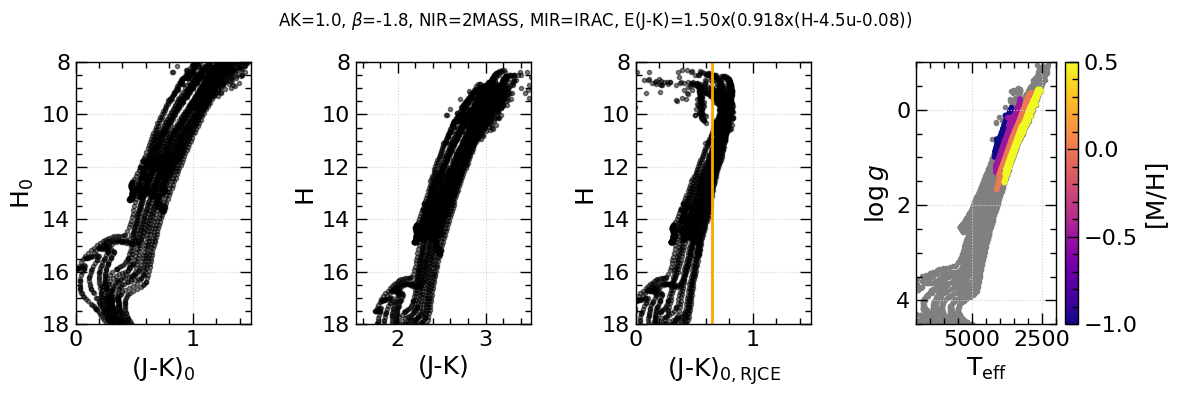

In [224]:
fig = test_dereddening()

### Different filter set, "standard" RJCE equations

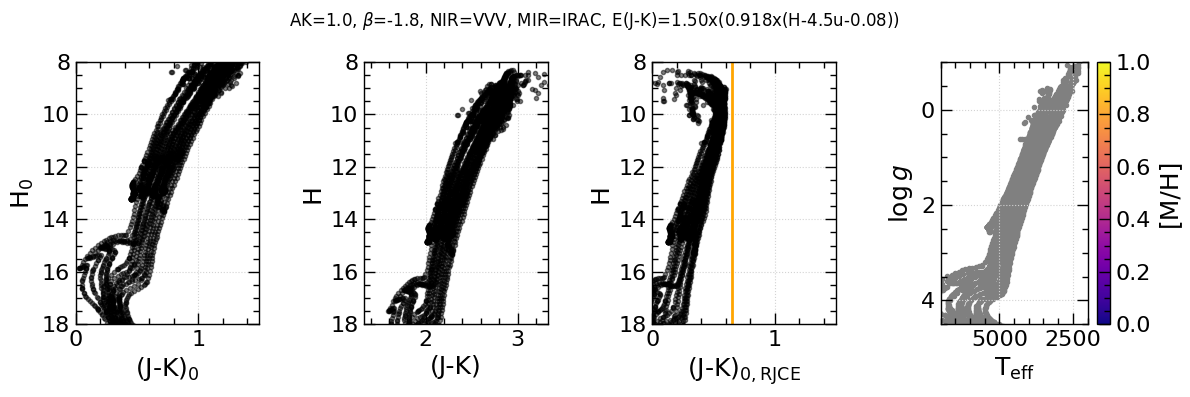

In [206]:
fig = test_dereddening(nirdata='VVV')

### 2MASS+IRAC data, customized RJCE equations

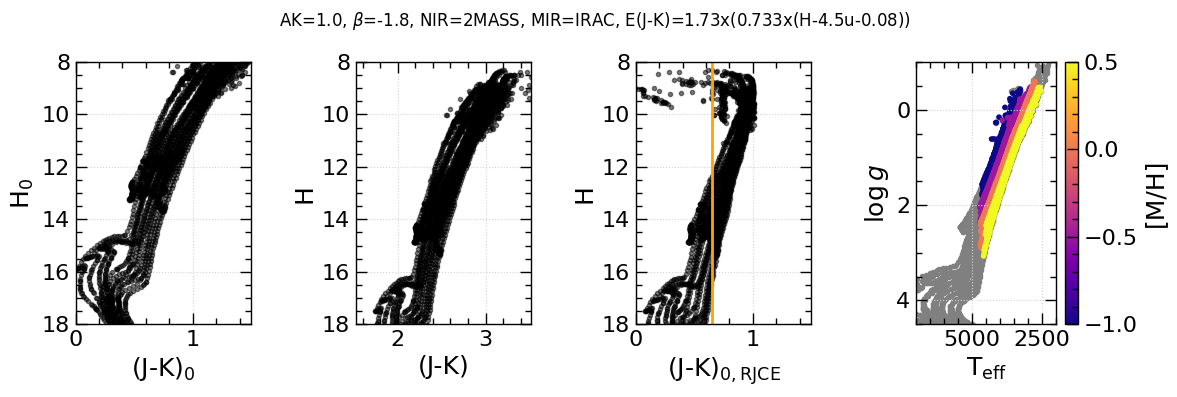

In [207]:
fig = test_dereddening(ejk_ak=get_rjce_ejkak(nirdata='2MASS'), rjce_coeff=get_rjce_coeff(nirdata='2MASS'))

### Different filter sets, customized RJCE equations

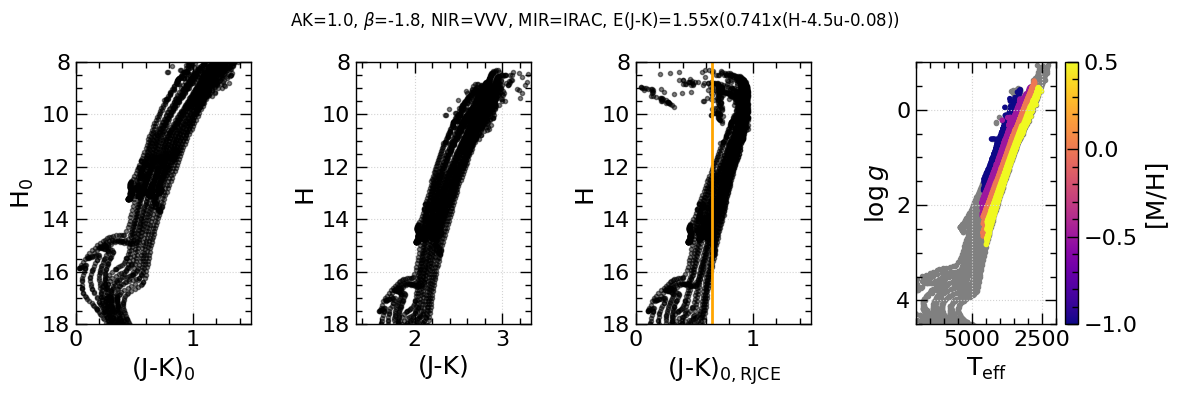

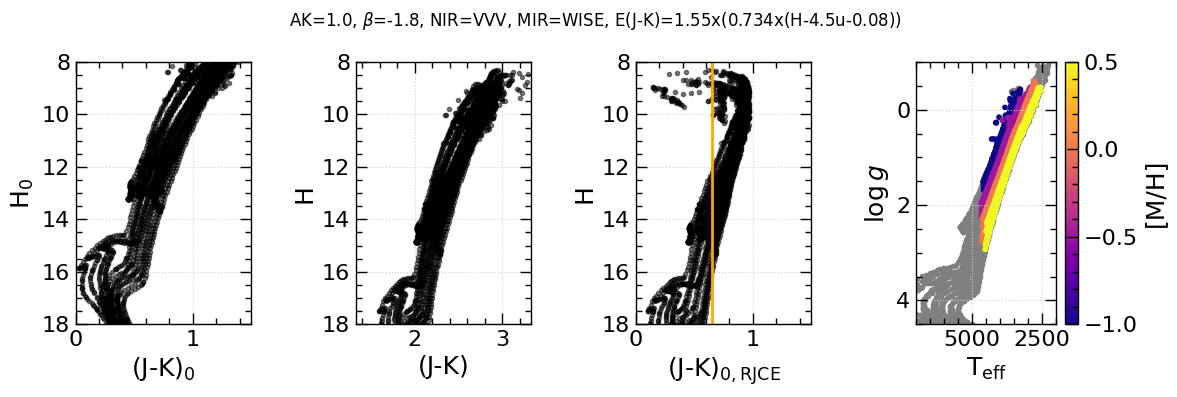

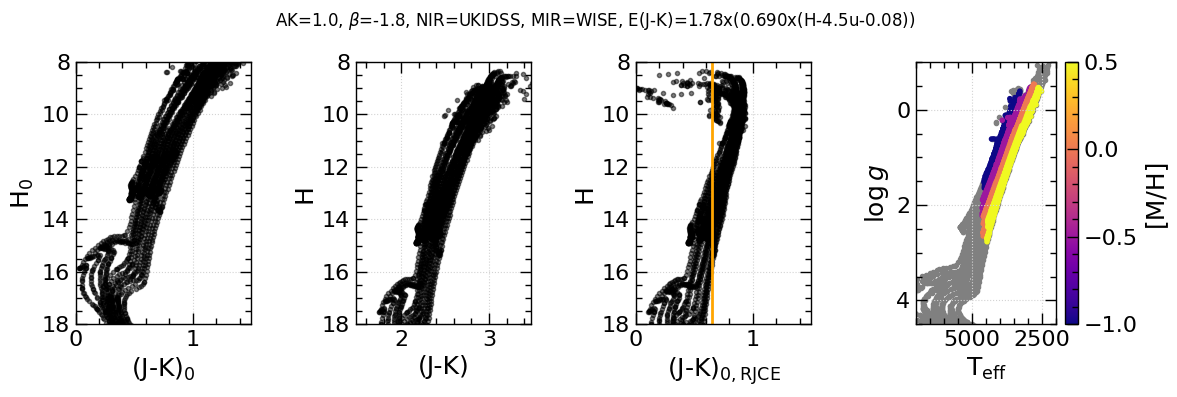

In [210]:
fig = test_dereddening(nirdata='VVV', ejk_ak=get_rjce_ejkak(nirdata='VVV'), rjce_coeff=get_rjce_coeff(nirdata='VVV'))
fig = test_dereddening(nirdata='VVV', mirdata='WISE', ejk_ak=get_rjce_ejkak(nirdata='VVV'), rjce_coeff=get_rjce_coeff(nirdata='VVV', mirdata='WISE'))
fig = test_dereddening(nirdata='UKIDSS', mirdata='WISE', ejk_ak=get_rjce_ejkak(nirdata='UKIDSS'), rjce_coeff=get_rjce_coeff(nirdata='UKIDSS', mirdata='WISE'))

### Customized RJCE equations, but a slightly wrong extinction law assumption

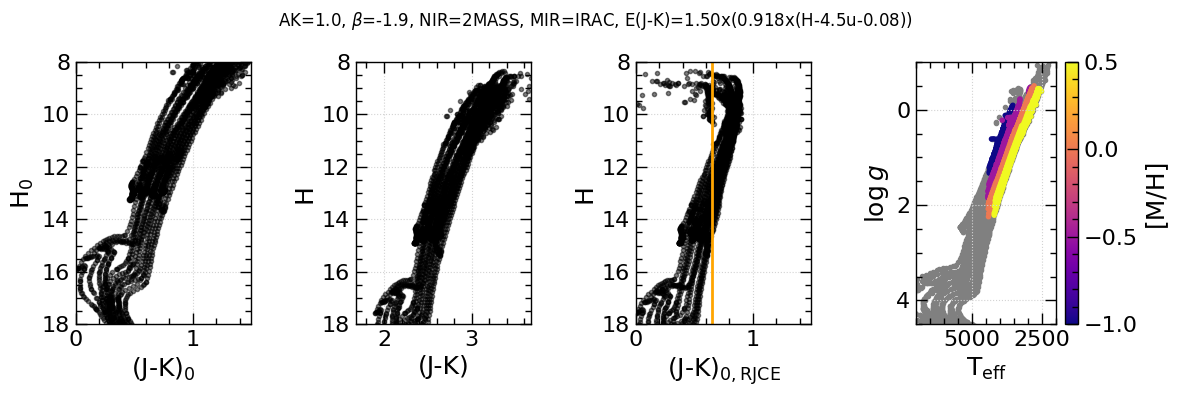

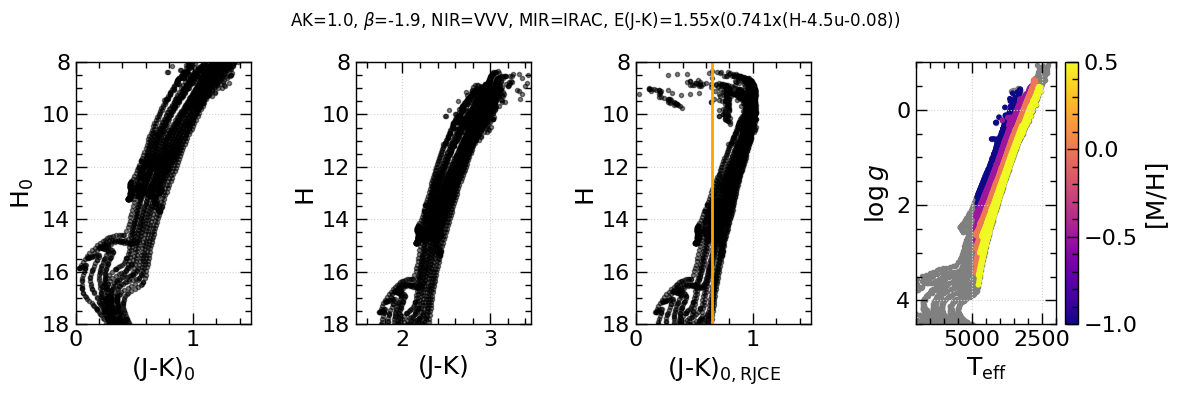

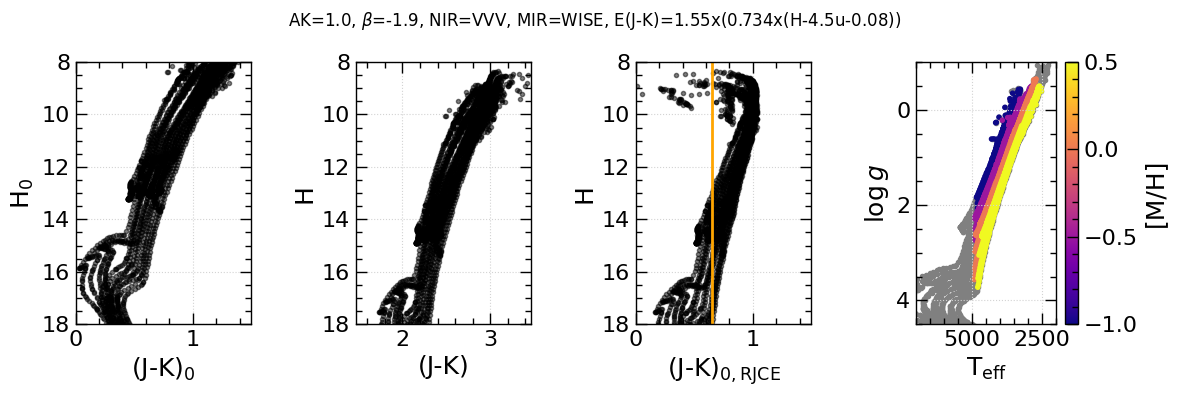

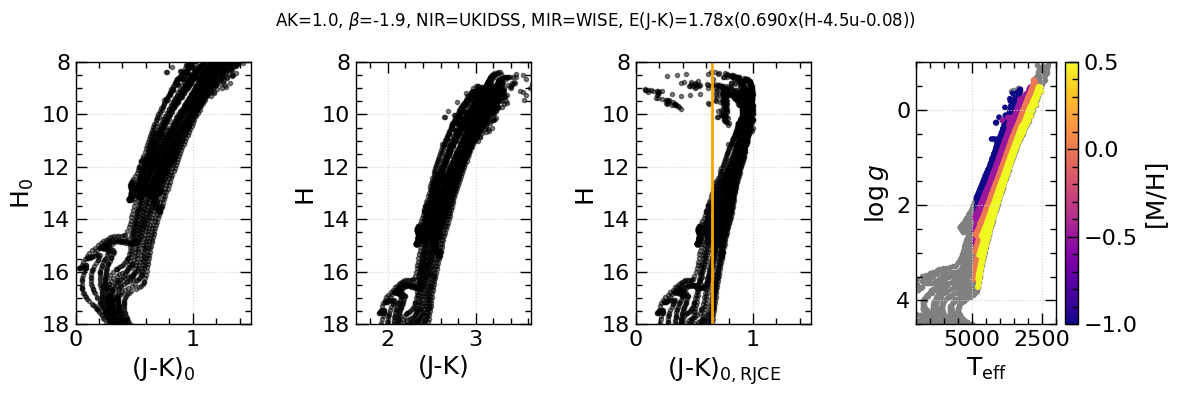

In [248]:
beta = -1.9 #default everywhere is -1.8
fig = test_dereddening(beta=beta)
fig = test_dereddening(beta=beta, nirdata='VVV', ejk_ak=get_rjce_ejkak(nirdata='VVV'), rjce_coeff=get_rjce_coeff(nirdata='VVV'))
fig = test_dereddening(beta=beta, nirdata='VVV', mirdata='WISE', ejk_ak=get_rjce_ejkak(nirdata='VVV'), rjce_coeff=get_rjce_coeff(nirdata='VVV', mirdata='WISE'))
fig = test_dereddening(beta=beta, nirdata='UKIDSS', mirdata='WISE', ejk_ak=get_rjce_ejkak(nirdata='UKIDSS'), rjce_coeff=get_rjce_coeff(nirdata='UKIDSS', mirdata='WISE'))